In [1]:
# 허깅페이스 - 가장 핵심적인 세개 라이브러리
# transformers : bert, gpt 등 사전학습된 모델
!pip install -U transformers
# 모델이 학습한 방식대로 텍스트를 쪼갠다(토크나이저)
!pip install -U tokenizers
!pip install -U datasets

  Using cached tokenizers-0.23.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.8 kB)
Using cached tokenizers-0.23.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.7.0 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.23.1 which is incompatible.


In [2]:
!pip uninstall -y transformers tokenizers

Found existing installation: transformers 5.7.0
Uninstalling transformers-5.7.0:
  Successfully uninstalled transformers-5.7.0
Found existing installation: tokenizers 0.23.1
Uninstalling tokenizers-0.23.1:
  Successfully uninstalled tokenizers-0.23.1


In [3]:
!pip install transformers

  Using cached transformers-5.7.0-py3-none-any.whl.metadata (33 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached transformers-5.7.0-py3-none-any.whl (10.5 MB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers] [transformers]


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import os
import shutil
import torch.optim as optim
from transformers import AutoTokenizer

In [5]:
import urllib.request

def get_file(filename, url):
  # 전체 경로 만듬
  save_file=os.path.join(os.getcwd(), filename)

  if not os.path.exists(save_file):
    print("download")
    # url내용 절대경로+파일명합친 경로에 저장하겠다.
    urllib.request.urlretrieve(url, save_file)
  else:
    print("already exists")

  return save_file

In [6]:
data_train=get_file("review_train2.txt","https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt" )
data_test=get_file("review_test2.txt","https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt" )

already exists
already exists


In [7]:
# read_csv로 데이터 가져와 shape확인한다
train_data=pd.read_csv(data_train, sep='\t')
test_data=pd.read_csv(data_test, sep='\t')

In [8]:
print(train_data.shape, test_data.shape)

(150000, 3) (50000, 3)


In [9]:
# 학습 15000, 테스트 5000개로 샘플링(섞는다)
# 결측치 확인
train_data=train_data.sample(n=15000, random_state=1)
test_data=test_data.sample(n=5000, random_state=1)

In [10]:
print(train_data.isna().sum())
print(test_data.isna().sum())

id          0
document    2
label       0
dtype: int64
id          0
document    0
label       0
dtype: int64


In [11]:
train_data.dropna(inplace=True)
print(train_data.isna().sum())

id          0
document    0
label       0
dtype: int64


In [12]:
train_data.head()

,id,document,label
58397,10040150,그런 여성은 21세기 잘 나가는 커리어 우먼으로 살아야 하는 타입이다. 시대와 맞지...,1
108538,9972114,왜 봤는지 모를 정말 재미없는 졸작 별하나도 아까움,0
149880,5627263,순수함에서 나온 커다란 감동과 아름다움을 준 따뜻한 영화. 오랜만에 목이 메였다.,1
127668,5470917,"어떤영화든, 자신에게 배울것을 주었다면 그것은 좋은영화이다.",1
66331,5547633,우리나라 용가리가 10배는 더 잘 만들었다.이런 3류영화도 개봉을 하나보네?,0


In [13]:
print(train_data.shape, test_data.shape)

(14998, 3) (5000, 3)


In [14]:
class_name={1:'긍정', 0:'부정'}

In [15]:
# 커스텀 데이터셋 정의
class MovieReview(Dataset):
  def __init__(self, documents, labels):
    self.documents=documents.tolist()
    self.labels=labels.tolist()

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    return self.documents[idx], self.labels[idx]

In [16]:
# 데이터셋 객체생성
train_dataset=MovieReview(train_data['document'], train_data['label'])
test_dataset=MovieReview(test_data['document'], test_data['label'])

In [17]:
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

In [18]:
len(train_loader)

469

In [19]:
data_iterate=iter(train_loader)
# 첫번째 배치 꺼내옴(32개)
next(data_iterate)

[['진짜 명작이다 벅차오르는 감동 열연.좋은 백그라운드 뮤직 배경 환상적',
  '쟁쟁한 코믹배우들이 출연해 잔뜩 기대했었지만, 막상 썰렁하기 그지없다.',
  '관객에게 머리쓰지 말고 감정선으로 영화를 재구축하라고 요구하는 영화',
  '주성치가 나이 먹어서 너무 아쉽다..',
  '등장인물들이 참.. 불쌍...근데 담배로 왜지짐? 역겹다 ㅡㅡ',
  '짧다면 짧지만 작은아이까지가서 봐서 우리가족은 만족햇어요.6살4살 흐믓하게 재미지게보고왓어요.',
  '아직도기분이알딸딸하다..그러나김C는분명미스캐스팅',
  '담배나사필걸...감독때문에 기대하고봤는데... 이건머? 공포아님.잘르는 그냥 미스테리정도임.다양성영화인듯. 레즈영화맞음.',
  '유치하다 시시하다시간아까운영화',
  '전체적으로 지루한스토리진행과 허무한반전 결론 재미없음',
  '완전 뻔하고 완전 삼류중에 삼류...',
  '많이 부족하다 북미에서 흥행 참패한 이유가 있었구만 릴리 콜린스는 진짜 이쁘더라 릴리 콜린스 아니었음 중간에 꺼버렸을 작품',
  '결국 또 한 사람이 쌩뚱맞게 죽어야 모든것이 나아지고 철드는 전형적인 억지감성 짜내기네. 후반부에 지나친 클리셰를 보고있자니 오그라든다.',
  '어렸을때 재밌게 봤는데 커서도 재밌네 이영화는... 이 헐크가 그립다',
  '맨오브스틸을 보고 나서 이 영화를 봐서 그런지 슈퍼맨 유니폼이 상당히 촌스럽다. 하지만 재미는 맨오브스틸에 버금갈만하다.',
  '그러고보니깐 송승헌 나온 영화 거의 다 흥행실패 했네... 드라마는 대박 많은데',
  '결말 이해안가요...',
  '희대의 쓰레기드라마 ㅋㅋ 작가 절필 추천',
  '굿!',
  '하드고어물로딱인거가틈',
  '겁나 잘생김 알랑드롱',
  '불쾌한 영화지만 왠지 남의 일만은 아닌거같아 더욱 씁쓸...',
  '넘좋아요 진짜로좋아요',
  '後部よし、信?よし！',
  '머 하나 하나 따져봐도 볼가치가없는 영화',
  '아 너무 좋은 노래에 영상! 쾌활해요~',
  '코언형제가 옳았다. 영화제 밖

In [20]:
document_batch, label_batch=next(data_iterate)
document_batch[0]

'잼재ㅁ잼잼잼댐잼잼잼'

In [21]:
class_names=['부정', '긍정']

In [22]:
for i in range(10):
  text=document_batch[i]
  label=label_batch[i].item()
  print(f'리뷰:{text}')
  print(f'label:{label}({class_name[label]})')

리뷰:잼재ㅁ잼잼잼댐잼잼잼
label:1(긍정)
리뷰:2시간동안 달랑 한건의 도둑질은 보는 이로 하여금 지루하게 만든다.
label:1(긍정)
리뷰:루이종과 쥘리, 정말 사랑스러운 캐릭터다. 이래서 세상이 아름다운 것일지도.
label:1(긍정)
리뷰:오드리 토투에 한번 낚이고 포스터에 두번 낚이고 평점에 세번 낚인 영화. 쒯!!
label:0(부정)
리뷰:삶의 소중함을 일깨워준 영화. 레너드의 어머니를 보며 눈물이 남.
label:1(긍정)
리뷰:전체관람가이긴한데 도영이 또래 아이들이 보기엔 좀 어려워요. 영화보고 아이에게 채식시키기에 대한 고민을 끝냈어요. 저처럼 육류뿐만 아니라 밀글루텐도 소화시키지 못하는 초식동양인을 위해 건강한 식품과 무글루텐 콩고기가 많아지길 바라며...
label:1(긍정)
리뷰:역시 티나페이와 스티브카렐 마이클 스캇과 리즈레몬을 좋아한다면 더욱 재밌게 볼 것같다
label:1(긍정)
리뷰:엄청 지루함.. 그닥 참신한지는 잘 모르겠다.. 솔직히 뭔 얘긴줄도 모르겠음..
label:0(부정)
리뷰:9..789.456.123 의 구조! 하지만 어지러운 앵글. 비슷한 구조의 메멘토에 비하자면 좀 떨어지는 듯... 재미로 영화를 보는 입장에게 흥미롭지는 않았음!
label:0(부정)
리뷰:울고싶을때 보고 또본다
label:1(긍정)


In [23]:
bert_name='bert-base-multilingual-cased'

model_id=bert_name

In [24]:
from transformers import AutoTokenizer, AutoModel

# model_id(bert모델명)
# 영화 너무 재미있어요 -> 모델마다 글자를 숫자로 바꾸는 사전, 규칙이 다 다르다
tokenizer=AutoTokenizer.from_pretrained(model_id)
# 구글에서 미리 텍스트로 공부시켜 놓은 사전학습모델
# 이미 학습이 끝난 가중치 다운로드
model=AutoModel.from_pretrained(model_id)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
print(tokenizer)

BertTokenizer(name_or_path='bert-base-multilingual-cased', vocab_size=119547, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [26]:
print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [27]:
text_test=['이 영화 너무 재밌어요!', '내용이 너무 싫다']
text_preprocess=tokenizer(text_test,
                          padding=True,
                          truncation=True,
                          return_tensors='pt')

In [28]:
print(text_preprocess.keys())
# cls : 101번
# sep : 102번

KeysView({'input_ids': tensor([[  101,  9638, 42428,  9004, 32537,   100,   106,   102],
        [  101,  8996, 96404,  9004, 32537,  9490, 11903,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1]])})


In [29]:
print(text_preprocess['input_ids'])

tensor([[  101,  9638, 42428,  9004, 32537,   100,   106,   102],
        [  101,  8996, 96404,  9004, 32537,  9490, 11903,   102]])


In [30]:
# bert모델 통과 -> 복합객체
outputs=model(**text_preprocess)
outputs.keys()

odict_keys(['last_hidden_state', 'pooler_output'])

In [31]:
# last_hidden_state : bert 마지막 층에서 나온 모든 토큰 벡터값(문장 내 각 단어 의미파악)
# pooler_output : 문장 전체의 의미를 대표하는 하나 벡터

In [32]:
# 모델 추론
with torch.no_grad():
  bert_results=model(**text_preprocess)

# 모델 통과 후 [배치크기, 벡터차원]
# 768개의 숫자를 입력받아 최종 판단을 내리게 된다
print(bert_results.pooler_output.shape)

# 문장에 포함된 8개 토큰에 대한 각각의 의미를 가지고 있는 벡터값
# 모델 통과 후 [배치크기, 문장 길이, 벡터 차원]
print(bert_results.last_hidden_state.shape)

torch.Size([2, 768])
torch.Size([2, 8, 768])


In [33]:
# bert모델 -> 12개 layer

In [34]:
class BertModel(nn.Module):
  def __init__(self, model_id):
    super().__init__()
    # 언어 문맥 파악하는 가중치와 bert모델 구조
    self.bert=AutoModel.from_pretrained(model_id)
    # 과적합 방지위해 10% 일부 노드 무작위로 끔(학습)
    self.dropout=nn.Dropout(0.1)
    # (768,1) -> linear : bert 뽑아진 특징들 (768)사이에서 14ㅐ
    self.classfier=nn.Linear(self.bert.config.hidden_size,1)

  def forward(self, input_ids, attention_mask, token_type_ids):
    outputs=self.bert(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids)

    pooled_output=outputs.pooler_output

    net=self.dropout(pooled_output)
    logits=self.classfier(net)

    return logits

In [35]:
# 데이터 들어왔을때 흐름
# 1. bert 통과 : input_ids, ..... 받아 문맥 파악
# 2. 문장 대표하는 768차원 뽑아옴
# 3. 뽑은 벡터에 dropout 입힘
# 4. 마지막 선형 레이어를 통과시켜 최종 점수를 만듬

In [36]:
model_id='bert-base-multilingual-cased'
model=BertModel(model_id)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [37]:
# dropout이 0%로 고정 -> 모든 노드 활성화
model.eval()

inputs={k:v.to(model.bert.device) for k,v in text_preprocess.items()}

with torch.no_grad():
  bert_results=model(**inputs)

print(bert_results)

prob=torch.sigmoid(bert_results)
print(prob)

tensor([[-0.2773],
        [-0.1800]])
tensor([[0.4311],
        [0.4551]])


In [38]:
!pip install torchinfo

In [39]:
# 요약표 제공해주는 라이브러리
from torchinfo import summary

In [40]:
# forward 함수 인자가 3개(input_ids(배치사이즈, 문장길이), mask, type_ids)
# 가상데이터를 넣어 모델 한번 돌려보려고 -> 흐름 추적
summary(model, input_size=[(1,12),(1,12),(1,12)],
        dtypes=[torch.long, torch.long, torch.long],
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        depth=3)

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Kernel Shape
BertModel                                               [1, 12]                   [1, 1]                    --                        --
├─BertModel: 1-1                                        --                        [1, 768]                  --                        --
│    └─BertEmbeddings: 2-1                              --                        [1, 12, 768]              --                        --
│    │    └─Embedding: 3-1                              [1, 12]                   [1, 12, 768]              91,812,096                --
│    │    └─Embedding: 3-2                              [1, 12]                   [1, 12, 768]              1,536                     --
│    │    └─Embedding: 3-3                              [1, 12]                   [1, 12, 768]              393,216                   --
│    │    └─LayerNorm: 3-4     

In [41]:
def binary_accuracy(preds, y):
  # 로짓을 0~1 사이 확률값
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()

    #평균값 계산
    acc = correct.sum() / len(correct)
    return acc

In [56]:
len(train_loader)

469

In [52]:
import torch.optim as optim
optimizer=optim.Adam(model.parameters(), lr=3e-5)

In [64]:
import time
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from torch.optim import Adam

epochs = 2
optimizer = Adam(model.parameters(), lr=3e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f'Training model with {model_id} on {device}\n')
start_time = time.time()

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
criterion = nn.BCEWithLogitsLoss()

for epoch in range(epochs):

    model.train()
    train_loss, train_correct = 0, 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for batch in train_bar:

        texts, labels = batch


        encoded_input = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        # 라벨 준비
        labels = labels.to(device).float().view(-1, 1)

        # 기울기 초기화
        optimizer.zero_grad()

        # 순전파 (Forward) - encoded_input 안의 ids, mask 등을 풀어 넣음
        logits = model(**encoded_input)
        loss = criterion(logits, labels)

        # 역전파 및 업데이트
        loss.backward()
        optimizer.step()


        # 통계
        train_loss += loss.item()
        preds = torch.sigmoid(logits) >= 0.5
        train_correct += (preds == labels).sum().item()

        train_bar.set_postfix(loss=f"{loss.item():.4f}")


    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            texts, labels = batch

            encoded_input = tokenizer(
                list(texts),
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ).to(device)

            labels = labels.to(device).float().view(-1, 1)

            logits = model(**encoded_input)
            loss = criterion(logits, labels)

            val_loss += loss.item()
            preds = torch.sigmoid(logits) >= 0.5
            val_correct += (preds == labels).sum().item()


    epoch_train_loss = train_loss / len(train_loader)
    epoch_train_acc = train_correct / len(train_dataset)
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc = val_correct / len(test_dataset)

    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    print(f">> Epoch {epoch+1} 결과")
    print(f"   Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}\n")


Training model with bert-base-multilingual-cased on cuda



Epoch 1/2 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/2 [Val]:   0%|          | 0/157 [00:00<?, ?it/s]

>> Epoch 1 결과
   Loss: 0.6945 | Acc: 0.4977 | Val Acc: 0.4990



Epoch 2/2 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/2 [Val]:   0%|          | 0/157 [00:00<?, ?it/s]

>> Epoch 2 결과
   Loss: 0.6941 | Acc: 0.5004 | Val Acc: 0.5010



In [65]:

model.eval()
test_loss = 0
test_correct = 0

# 기울기 계산 비활성화 (메모리 절약 및 속도 향상)
with torch.no_grad():
    # 진행률 표시 (선택 사항)
    test_bar = tqdm(test_loader, desc="Evaluating")

    for batch in test_bar:
        # 데이터 준비 (문자열 리스트, 라벨 텐서)
        texts, labels = batch

        # 토크나이징 및 GPU 이동
        encoded_input = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        labels = labels.to(device).float().view(-1, 1)

        # 모델 예측
        logits = model(**encoded_input)

        # 손실 계산
        loss = criterion(logits, labels)
        test_loss += loss.item()

        # 정확도 계산
        preds = torch.sigmoid(logits) >= 0.5
        test_correct += (preds == labels).sum().item()

# 최종 평균값 계산
final_loss = test_loss / len(test_loader)
final_accuracy = test_correct / len(test_dataset)

print(f'Loss: {final_loss:.4f}')
print(f'Accuracy: {final_accuracy:.4f}')

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Loss: 0.6941
Accuracy: 0.5010


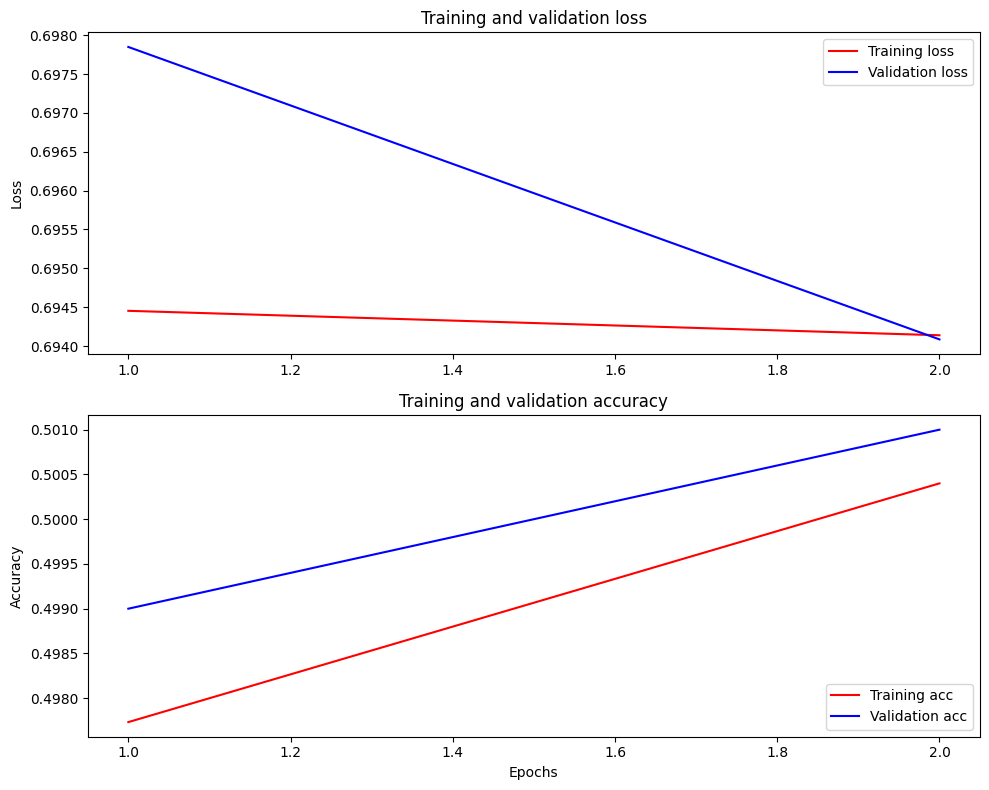

In [66]:
import matplotlib.pyplot as plt

# 학습 루프에서 저장한 history 딕셔너리 사용
# print(history.keys()) -> dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']

epochs_range = range(1, len(acc) + 1)

fig = plt.figure(figsize=(10, 8))

# Loss 그래프
plt.subplot(2, 1, 1)
plt.plot(epochs_range, loss, 'r', label='Training loss')
plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(2, 1, 2)
plt.plot(epochs_range, acc, 'r', label='Training acc')
plt.plot(epochs_range, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.tight_layout() # 서브플롯 간 간격 자동 조절
plt.show()

In [63]:
import os

# 저장 경로 설정
dataset_name = 'kor_movie'
saved_model_path = './{}_bert'.format(dataset_name.replace('/', '_'))

# 폴더 생성 (경로가 없으면 생성)
os.makedirs(saved_model_path, exist_ok=True)

# 모델 저장 (Hugging Face 방식)

torch.save(model.state_dict(), os.path.join(saved_model_path, 'model_weights.pth'))


# model.bert.save_pretrained(saved_model_path)

print(f"모델이 경로에 저장: {saved_model_path}")

모델이 경로에 저장: ./kor_movie_bert


In [49]:


reloaded_model = BertModel(model_id)

# 저장된 가중치 파일 경로 설정
weights_path = os.path.join(saved_model_path, 'model_weights.pth')

# 가중치 불러오기
state_dict = torch.load(weights_path, map_location=device)
# 딕셔너리 형태 -> 가중치 값들을 모델의 각 레이어에 넣는다
reloaded_model.load_state_dict(state_dict)

reloaded_model.to(device)
reloaded_model.eval()

print(f"모델이 경로에서 성공적으로 로드: {weights_path}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_1536/3169053755.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execu

모델이 경로에서 성공적으로 로드: ./kor_movie_bert/model_weights.pth


In [51]:
def my_review(inputs, results):
    result=[
        f'review:{inputs[i]:<30} : score : {results[i][0]:4f}' for i in range(len(inputs))
    ]

    print(*result, sep='\n')
    print()

examples=[
    text_test[0],
    '영화는 밋밋했다',
    '너무 훌륭한 영화였다',
    '영화는 재미있었다',
    '너무 끔찍하고 잔인한 영화',
    '그럭저럭 재밌었다'
]

reloaded_model.eval()

example_inputs=tokenizer(examples,
                         padding=True,
                         truncation=True,
                         return_tensors="pt").to(device)

with torch.no_grad():
    logits=reloaded_model(**example_inputs)
    reloaded_result=torch.sigmoid(logits).cpu().numpy()


my_review(examples, reloaded_result)
    

review:이 영화 너무 재밌어요!                  : score : 0.480707
review:영화는 밋밋했다                       : score : 0.480707
review:너무 훌륭한 영화였다                    : score : 0.480707
review:영화는 재미있었다                      : score : 0.480707
review:너무 끔찍하고 잔인한 영화                 : score : 0.480707
review:그럭저럭 재밌었다                      : score : 0.480707

